
===== Assignment distance QC =====

POST  n=79,899,938
Median : 0.0864 μm
Mean   : 0.1593 μm
P90    : 0.3659 μm
P95    : 0.5188 μm
P99    : 1.0424 μm
Max    : 54.2764 μm
≤   0.1 μm :  56.85%
≤  0.25 μm :  82.53%
≤   0.5 μm :  94.58%
≤     1 μm :  98.88%
≤     2 μm :  99.93%
≤     5 μm : 100.00%
≤    10 μm : 100.00%

PRE  n=79,933,904
Median : 0.3210 μm
Mean   : 0.3528 μm
P90    : 0.5841 μm
P95    : 0.6979 μm
P99    : 1.0528 μm
Max    : 54.8536 μm
≤   0.1 μm :   4.73%
≤  0.25 μm :  32.32%
≤   0.5 μm :  82.74%
≤     1 μm :  98.78%
≤     2 μm :  99.94%
≤     5 μm : 100.00%
≤    10 μm : 100.00%

===== Long-distance assignments =====

POST
>  1 μm : 892,639 (1.117196%)
>  2 μm : 53,358 (0.066781%)
>  5 μm : 2,886 (0.003612%)
> 10 μm : 414 (0.000518%)
> 20 μm : 101 (0.000126%)

PRE
>  1 μm : 973,614 (1.218024%)
>  2 μm : 45,379 (0.056771%)
>  5 μm : 2,694 (0.003370%)
> 10 μm : 464 (0.000580%)
> 20 μm : 123 (0.000154%)


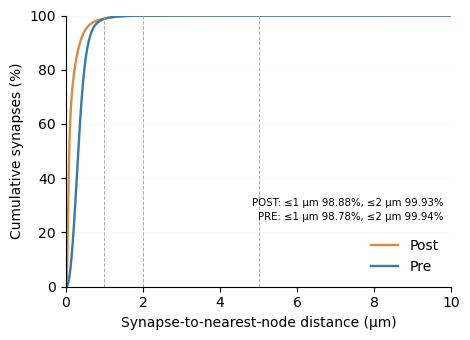

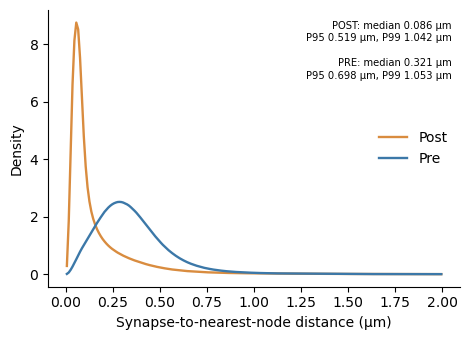

In [1]:
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt

root=Path("/data/project_backup/swc_fix/step5_2_out")
out=root/"synapse_assignment_qc"; out.mkdir(exist_ok=True)

df=pd.read_csv(root/"synapse_distance_all.csv")
TH=[.1,.25,.5,1,2,5,10]
colors={"pre":"#3C78A8","post":"#D98C3F"}

df["distance_um"]=pd.to_numeric(df.distance_um,errors="coerce")
df=df[np.isfinite(df.distance_um)&(df.distance_um>=0)]

rows=[]
for g,x in df.groupby("syn_type"):
    d=x.distance_um.values
    r={"syn_type":g,"n":len(d),"mean":d.mean(),"median":np.median(d),
       "p90":np.quantile(d,.90),"p95":np.quantile(d,.95),
       "p99":np.quantile(d,.99),"max":d.max()}
    for t in TH:r[f"pct_le_{t:g}um"]=(d<=t).mean()*100
    rows.append(r)

s=pd.DataFrame(rows).set_index("syn_type")
s.to_csv(out/"assignment_distance_summary.csv")

print("\n===== Assignment distance QC =====")
for g,r in s.iterrows():
    print(f"\n{g.upper()}  n={int(r.n):,}")
    print(f"Median : {r['median']:.4f} μm")
    print(f"Mean   : {r['mean']:.4f} μm")
    print(f"P90    : {r.p90:.4f} μm")
    print(f"P95    : {r.p95:.4f} μm")
    print(f"P99    : {r.p99:.4f} μm")
    print(f"Max    : {r['max']:.4f} μm")
    for t in TH:print(f"≤ {t:>5g} μm : {r[f'pct_le_{t:g}um']:6.2f}%")

print("\n===== Long-distance assignments =====")
for g,x in df.groupby("syn_type"):
    d=x.distance_um.values
    print(f"\n{g.upper()}")
    for t in [1,2,5,10,20]:
        print(f"> {t:2d} μm : {(d>t).sum():,} ({(d>t).mean()*100:.6f}%)")

# CDF
fig,ax=plt.subplots(figsize=(4.8,3.5))
bins=np.linspace(0,10,2001)

for g,x in df.groupby("syn_type"):
    d=x.distance_um.to_numpy()
    h,_=np.histogram(d,bins=bins)
    cdf=np.cumsum(h)/len(d)*100
    ax.plot(bins[1:],cdf,lw=1.7,color=colors[g],label=g.capitalize())

for t in [1,2,5]:ax.axvline(t,color="#AAAAAA",lw=.7,ls="--")

ax.set(xlabel="Synapse-to-nearest-node distance (μm)",
       ylabel="Cumulative synapses (%)",xlim=(0,10),ylim=(0,100))
ax.legend(frameon=False,loc="lower right")
ax.spines[["top","right"]].set_visible(False)
ax.tick_params(direction="out")
ax.yaxis.grid(True,lw=.4,alpha=.15)

txt=[]
for g in ["post","pre"]:
    r=s.loc[g]
    txt.append(
        f"{g.upper()}: ≤1 μm {r['pct_le_1um']:.2f}%, "
        f"≤2 μm {r['pct_le_2um']:.2f}%"
    )

ax.text(.98,.24,"\n".join(txt),transform=ax.transAxes,
        ha="right",va="bottom",fontsize=7.3,linespacing=1.4)

plt.tight_layout()
plt.savefig(out/"assignment_distance_cdf.pdf",bbox_inches="tight")
plt.savefig(out/"assignment_distance_cdf.png",dpi=600,bbox_inches="tight")
plt.show()

# Distribution
fig,ax=plt.subplots(figsize=(4.8,3.5))
bins=np.linspace(0,2,201)

for g,x in df.groupby("syn_type"):
    d=x.distance_um.to_numpy()
    h,e=np.histogram(d,bins=bins,density=True)
    center=(e[:-1]+e[1:])/2
    ax.plot(center,h,lw=1.7,color=colors[g],label=g.capitalize())

ax.set(xlabel="Synapse-to-nearest-node distance (μm)",ylabel="Density")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
ax.tick_params(direction="out")

txt=[]
for g in ["post","pre"]:
    r=s.loc[g]
    txt.append(
        f"{g.upper()}: median {r['median']:.3f} μm\n"
        f"P95 {r.p95:.3f} μm, P99 {r.p99:.3f} μm"
    )

ax.text(.98,.96,"\n\n".join(txt),transform=ax.transAxes,
        ha="right",va="top",fontsize=7.2,linespacing=1.3)

plt.tight_layout()
plt.savefig(out/"assignment_distance_distribution.pdf",bbox_inches="tight")
plt.savefig(out/"assignment_distance_distribution.png",dpi=600,bbox_inches="tight")
plt.show()

In [2]:
import os, json, pickle, hashlib, warnings, shutil
from pathlib import Path
from multiprocessing import get_context
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import trimesh
from tqdm import tqdm

warnings.filterwarnings("ignore")

CFG = {
    "swc_dir": "/data/project_backup/swc_fix/step6_2_out/soma_pruned",
    "mesh_dir": "/data/project_backup/swc_fix/fly_mesh",
    "out_dir": "/data/project_backup/swc_fix/branch_order_neuropil_analysis2",
    "types": [2, 3, 4],
    "scale": [1000, 1000, 1000],
    "processes": 8,
    "batch_files": 300,
    "reset": False,
    "include_outside": True,
    "dpi": 300,
}

SCALE = np.asarray(CFG["scale"], float)
MESHES, BOUNDS = {}, {}


def clear_dir(p):
    p = Path(p)
    if p.exists(): shutil.rmtree(p)
    p.mkdir(parents=True, exist_ok=True)


def load_mesh(p):
    m = trimesh.load(p, process=False)
    if isinstance(m, trimesh.Scene):
        m = trimesh.util.concatenate([x for x in m.geometry.values() if isinstance(x, trimesh.Trimesh)])
    return m


def load_meshes(d):
    global MESHES, BOUNDS
    MESHES = {p.stem: load_mesh(p) for p in sorted(Path(d).glob("*.obj"))}
    BOUNDS = {k: np.asarray(m.bounds) for k, m in MESHES.items()}


def read_swc(p):
    d = pd.read_csv(p, sep=r"\s+", comment="#", header=None, usecols=range(7))
    d.columns = ["ID", "Type", "X", "Y", "Z", "Radius", "Parent"]
    d[["ID", "Type", "Parent"]] = d[["ID", "Type", "Parent"]].astype(int)
    return d


def branch_orders(d):
    ids, typ, par = d.ID.to_numpy(int), d.Type.to_numpy(int), d.Parent.to_numpy(int)
    pos, n = {v:i for i,v in enumerate(ids)}, len(ids)
    child, roots = [[] for _ in range(n)], []

    for i,p in enumerate(par):
        j = pos.get(p)
        roots.append(i) if p == -1 or j is None else child[j].append(i)

    if not roots: raise ValueError("No root")

    order, seen = np.ones(n, np.int16), np.zeros(n, bool)
    for r in roots:
        stack = [(r, 0 if typ[r] == 1 else 1)]
        while stack:
            i,o = stack.pop()
            if seen[i]: continue
            seen[i], order[i] = True, o
            for c in child[i]:
                co = 1 if o == 0 else o
                if len(child[c]) >= 2 and typ[c] != 1: co += 1
                stack.append((c, co))
    return order


def assign_neuropil(xyz):
    lab = np.full(len(xyz), "OUTSIDE", object)

    for name, mesh in MESHES.items():
        lo, hi = BOUNDS[name]
        idx = np.flatnonzero(np.all((xyz >= lo) & (xyz <= hi), 1))
        if not len(idx): continue

        try:
            hit = idx[np.asarray(mesh.contains(xyz[idx]), bool)]
        except Exception:
            continue

        first = lab[hit] == "OUTSIDE"
        lab[hit[first]] = name
        for i in hit[~first]: lab[i] += "|" + name

    return lab


def process_batch(task):
    bid, paths, root = task
    root = Path(root)
    sm, xyzs, types, orders, fids = [], [], [], [], []

    for fi,p in enumerate(map(Path, paths)):
        try:
            d, rel = read_swc(p), str(p.relative_to(root))
            bo = branch_orders(d)
            idx = np.flatnonzero(d.Type.isin(CFG["types"]).to_numpy())
            sm.append({"file":rel,"n_target_nodes":len(idx),"n_outside":0,"n_multi":0,"skipped":False})

            if not len(idx): continue
            x = d.iloc[idx]
            xyzs.append(x[["X","Y","Z"]].to_numpy(float) / SCALE)
            types.append(x.Type.to_numpy(np.int8))
            orders.append(bo[idx])
            fids.append(np.full(len(idx), fi, np.int32))

        except Exception:
            sm.append({"file":str(p.relative_to(root)),"n_target_nodes":0,"n_outside":0,"n_multi":0,"skipped":True})

    if not xyzs: return bid, sm, []

    xyz, typ, bo, fid = map(np.concatenate, [xyzs, types, orders, fids])
    neu = assign_neuropil(xyz)
    outside = neu == "OUTSIDE"
    multi = np.fromiter(("|" in str(x) for x in neu), bool, len(neu))

    oc, mc = np.bincount(fid[outside], minlength=len(paths)), np.bincount(fid[multi], minlength=len(paths))
    for i in range(len(sm)):
        sm[i]["n_outside"], sm[i]["n_multi"] = int(oc[i]), int(mc[i])

    z = pd.DataFrame({"file_idx":fid,"node_type":typ,"neuropil":neu,"branch_order":bo})
    if not CFG["include_outside"]: z = z[z.neuropil != "OUTSIDE"]

    g = z.groupby(["file_idx","node_type","neuropil","branch_order"], observed=True).size().reset_index(name="node_count")
    rec = [{"file":sm[r.file_idx]["file"],"node_type":int(r.node_type),"neuropil":r.neuropil,
            "branch_order":int(r.branch_order),"node_count":int(r.node_count)}
           for r in g.itertuples(index=False)]
    return bid, sm, rec


def cp_path(d, i):
    return d / f"batch_{i:06d}.pkl"


def save_cp(obj, p):
    tmp = p.with_suffix(".tmp")
    with open(tmp, "wb") as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)
        f.flush(); os.fsync(f.fileno())
    os.replace(tmp, p)


def task_signature(files, meshes):
    h = hashlib.sha256()
    for p in [*files, *meshes]:
        s = p.stat()
        h.update(f"{p}|{s.st_size}|{s.st_mtime_ns}\n".encode())
    h.update(json.dumps({k:CFG[k] for k in ["types","scale","batch_files","include_outside"]}, sort_keys=True).encode())
    return h.hexdigest()


def check_manifest(out, files, meshes):
    p, sig = out/"_manifest.json", task_signature(files, meshes)
    if p.exists() and json.loads(p.read_text()).get("signature") != sig:
        raise RuntimeError('Checkpoint does not match current task. Set "reset": True to restart.')
    if not p.exists(): p.write_text(json.dumps({"signature":sig}, indent=2))


def make_tables(summary_rows, records):
    s, d = pd.DataFrame(summary_rows), pd.DataFrame(records)
    if d.empty: return s, d, pd.DataFrame(), pd.DataFrame()

    d["fraction"] = d.node_count / d.groupby(["file","node_type","neuropil"]).node_count.transform("sum")

    pooled = d.groupby(["node_type","neuropil","branch_order"], as_index=False).agg(
        node_count=("node_count","sum"), n_neurons=("file","nunique"))
    pooled["node_fraction"] = pooled.node_count / pooled.groupby(["node_type","neuropil"]).node_count.transform("sum")

    out = []
    for (t,n),g in d.groupby(["node_type","neuropil"]):
        p = g.pivot_table(index="file", columns="branch_order", values="fraction", fill_value=0)
        for o in p.columns:
            v = p[o].to_numpy(float)
            sd = v.std(ddof=1) if len(v)>1 else 0
            out.append({"node_type":int(t),"neuropil":n,"branch_order":int(o),"n_neurons":len(v),
                        "mean_fraction":v.mean(),"median_fraction":np.median(v),
                        "std_fraction":sd,"sem_fraction":sd/np.sqrt(len(v)) if len(v)>1 else 0})

    return s, d, pooled, pd.DataFrame(out)


def plot_heatmaps(d, out):
    for t in CFG["types"]:
        x = d[(d.node_type==t) & ~d.neuropil.astype(str).str.contains(r"\|")]
        if not CFG["include_outside"]: x = x[x.neuropil!="OUTSIDE"]
        if x.empty: continue

        p = x.pivot_table(index="neuropil", columns="branch_order", values="mean_fraction", fill_value=0).sort_index()
        p = p[sorted(p.columns)]

        fig, ax = plt.subplots(figsize=(8, max(5, len(p)*.22)))
        im = ax.imshow(p.values, aspect="auto", interpolation="nearest")
        ax.set(xticks=np.arange(len(p.columns)), yticks=np.arange(len(p.index)),
               xlabel="Branch order", ylabel="Neuropil", title=f"Type {t}")
        ax.set_xticklabels(p.columns); ax.set_yticklabels(p.index)
        fig.colorbar(im, ax=ax, label="Mean fraction across neurons")
        fig.tight_layout()
        fig.savefig(out/f"type{t}_neuropil_branch_order_heatmap.png", dpi=CFG["dpi"], bbox_inches="tight")
        plt.close(fig)


def run():
    root, mesh_dir, out = map(Path, [CFG["swc_dir"], CFG["mesh_dir"], CFG["out_dir"]])
    cp = out/"_checkpoints"

    if CFG["reset"]: clear_dir(out)
    out.mkdir(parents=True, exist_ok=True); cp.mkdir(parents=True, exist_ok=True)

    files, mesh_files = sorted(root.rglob("*.swc")), sorted(mesh_dir.glob("*.obj"))
    batches = [files[i:i+CFG["batch_files"]] for i in range(0,len(files),CFG["batch_files"])]

    check_manifest(out, files, mesh_files)
    load_meshes(mesh_dir)

    done = {int(p.stem.split("_")[1]) for p in cp.glob("batch_*.pkl")}
    pending = [i for i in range(len(batches)) if i not in done]

    print("SWC files:", len(files))
    print("Meshes:", len(MESHES))
    print("Batches:", len(batches), "| Completed:", len(done), "| Remaining:", len(pending))

    if pending:
        tasks = [(i,[str(x) for x in batches[i]],str(root)) for i in pending]
        pool = get_context("fork").Pool(CFG["processes"])

        try:
            for bid,sm,rec in tqdm(
                pool.imap_unordered(process_batch, tasks, chunksize=1),
                total=len(tasks), desc="Processing"
            ):
                save_cp({"summary":sm,"records":rec}, cp_path(cp,bid))
            pool.close(); pool.join()

        except BaseException:
            pool.terminate(); pool.join()
            print("\nInterrupted. Completed checkpoints are preserved.")
            raise

    missing = [i for i in range(len(batches)) if not cp_path(cp,i).exists()]
    if missing:
        print("Remaining unfinished batches:", len(missing))
        return

    summary_rows, records = [], []
    for i in tqdm(range(len(batches)), desc="Loading checkpoints"):
        with open(cp_path(cp,i),"rb") as f: x = pickle.load(f)
        summary_rows.extend(x["summary"]); records.extend(x["records"])

    summary, per_neuron, pooled, normalized = make_tables(summary_rows, records)

    summary.to_csv(out/"file_summary.csv", index=False)
    per_neuron.to_csv(out/"branch_order_per_neuron.csv", index=False)
    pooled.to_csv(out/"branch_order_pooled_distribution.csv", index=False)
    normalized.to_csv(out/"branch_order_neuron_normalized_distribution.csv", index=False)
    plot_heatmaps(normalized, out)

    print("\nFiles:", len(summary))
    print("Skipped:", int(summary.skipped.sum()))
    print("Type 2/3/4 nodes:", int(summary.n_target_nodes.sum()))
    print("Outside:", int(summary.n_outside.sum()))
    print("Multiple neuropil hits:", int(summary.n_multi.sum()))

    return summary, per_neuron, pooled, normalized


if __name__ == "__main__":
    result = run()
    if result is not None:
        summary, per_neuron, pooled, normalized = result

SWC files: 117662
Meshes: 78
Batches: 393 | Completed: 0 | Remaining: 393


Loading checkpoints: 100%|███████████████████████████████████████████| 393/393 [00:07<00:00, 52.91it/s]



Files: 117662
Skipped: 0
Type 2/3/4 nodes: 97563670
Outside: 3407893
Multiple neuropil hits: 886


Neurons: 117662
With OUTSIDE: 111855 (95.06%)
Median OUTSIDE nodes: 13.0
Mean OUTSIDE nodes: 28.963412146657376
Median OUTSIDE fraction: 0.02268041237113402
Mean OUTSIDE fraction: 0.06306454759646038
Top 1% neurons contain 18.40% of OUTSIDE nodes
Top 5% neurons contain 36.92% of OUTSIDE nodes
Top 10% neurons contain 50.77% of OUTSIDE nodes
Top 20% neurons contain 67.55% of OUTSIDE nodes
Top 50% neurons contain 90.56% of OUTSIDE nodes


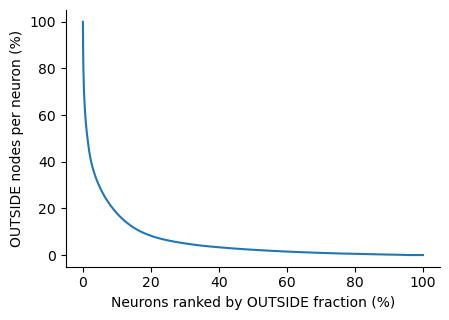

In [3]:
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt

root=Path("/data/project_backup/swc_fix/branch_order_neuropil_analysis2")
df=pd.read_csv(root/"file_summary.csv")
df=df[~df.skipped].copy()

df["outside_fraction"]=df.n_outside/df.n_target_nodes.replace(0,np.nan)

print("Neurons:",len(df))
print("With OUTSIDE:",(df.n_outside>0).sum(),
      f"({(df.n_outside>0).mean()*100:.2f}%)")
print("Median OUTSIDE nodes:",df.n_outside.median())
print("Mean OUTSIDE nodes:",df.n_outside.mean())
print("Median OUTSIDE fraction:",df.outside_fraction.median())
print("Mean OUTSIDE fraction:",df.outside_fraction.mean())

x=df.loc[df.n_outside>0,"n_outside"].sort_values(ascending=False).values
if len(x):
    cs=np.cumsum(x)/x.sum()
    for p in [.01,.05,.10,.20,.50]:
        k=max(1,int(np.ceil(len(x)*p)))
        print(f"Top {p*100:.0f}% neurons contain {cs[k-1]*100:.2f}% of OUTSIDE nodes")

fig,ax=plt.subplots(figsize=(4.6,3.3))
z=np.sort(df.outside_fraction.dropna().values)[::-1]
ax.plot(np.arange(1,len(z)+1)/len(z)*100,z*100,lw=1.5)
ax.set(xlabel="Neurons ranked by OUTSIDE fraction (%)",
       ylabel="OUTSIDE nodes per neuron (%)")
ax.spines[["top","right"]].set_visible(False)
ax.tick_params(direction="out")
plt.tight_layout()
plt.show()

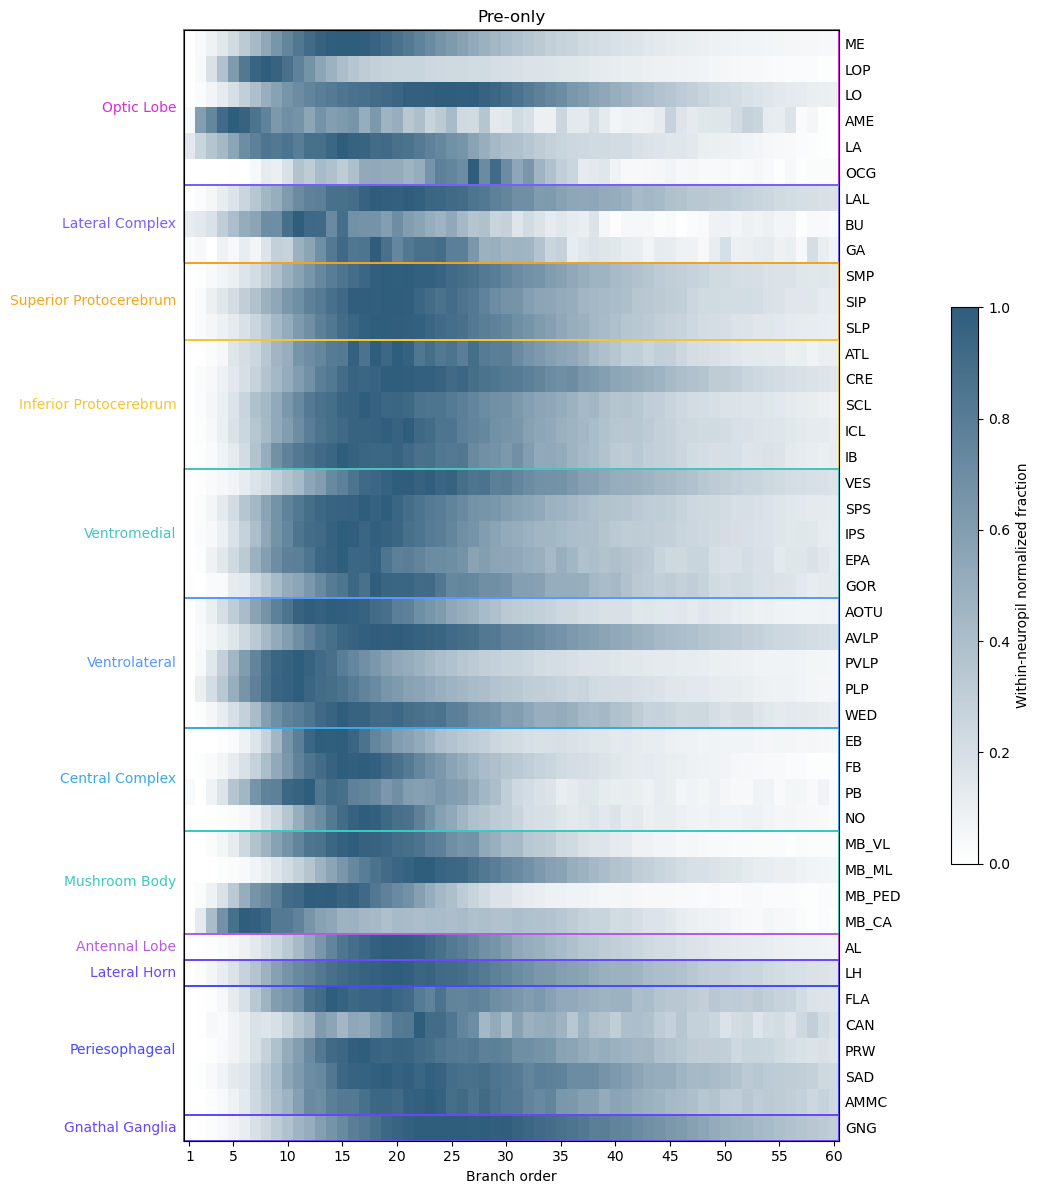

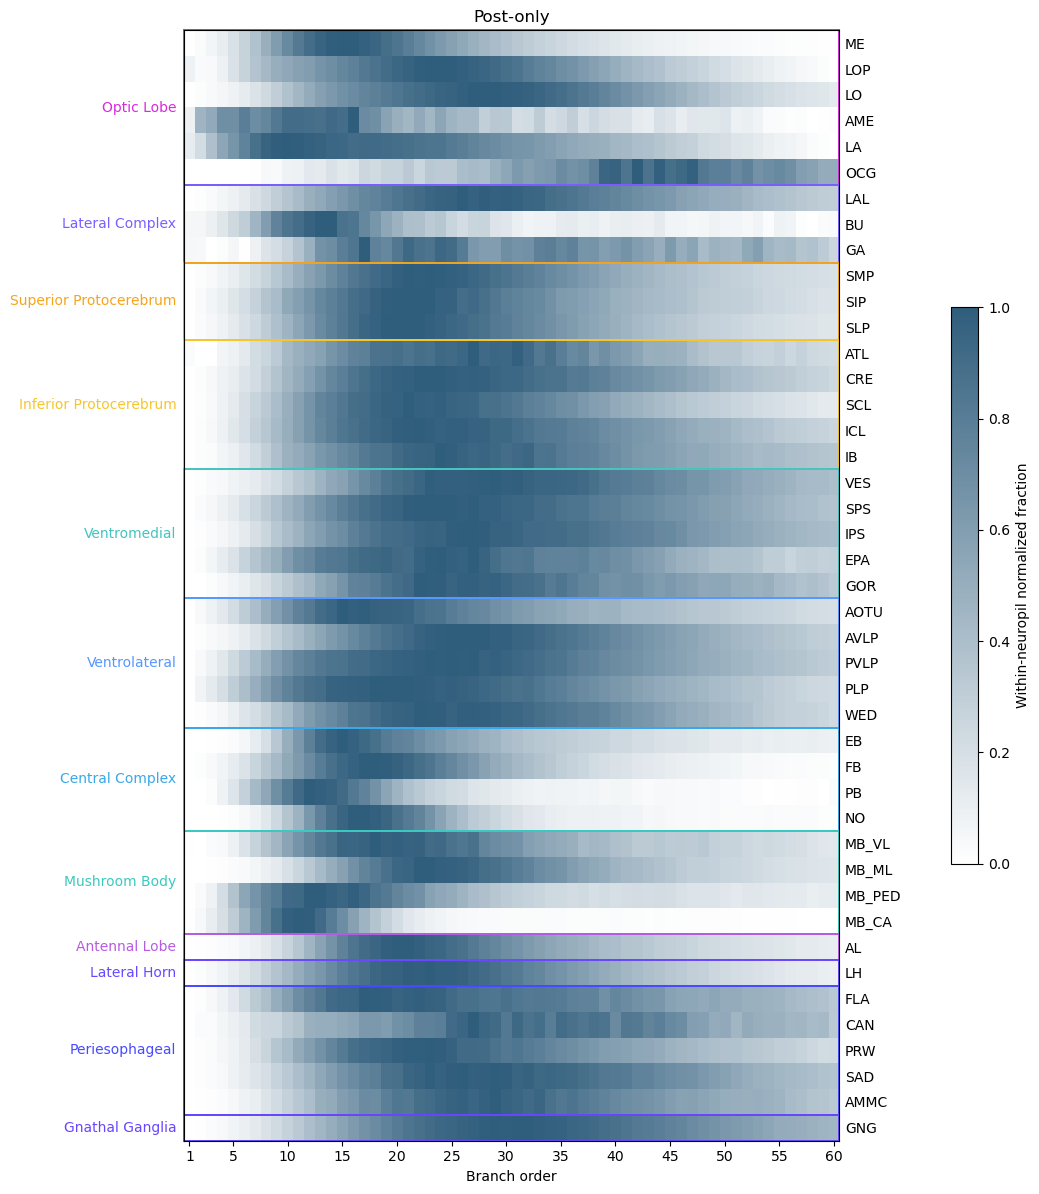

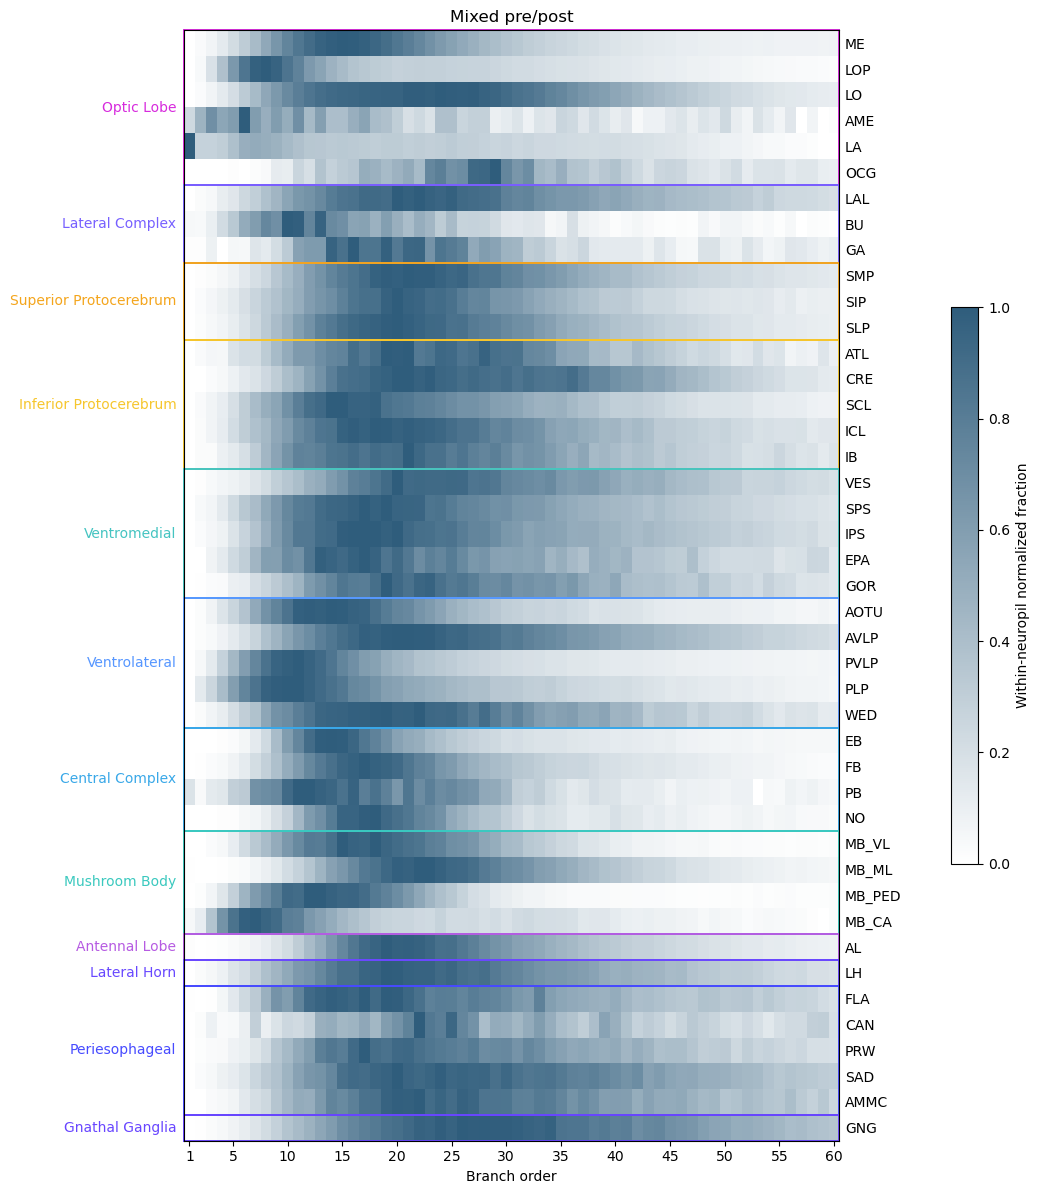

In [4]:
import warnings
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

OUT=Path("/data/project_backup/swc_fix/branch_order_neuropil_analysis2")
IN=OUT/"branch_order_per_neuron.csv"
OMIN,OMAX,DPI=1,60,300
ORDERS=np.arange(OMIN,OMAX+1)

TYPE_LABEL={2:("Pre-only","pre_only"),3:("Post-only","post_only"),4:("Mixed pre/post","mixed_pre_post")}

GROUPS=[
    ("Optic Lobe",["ME","LOP","LO","AME","LA","OCG"]),
    ("Lateral Complex",["LAL","BU","GA"]),
    ("Superior Protocerebrum",["SMP","SIP","SLP"]),
    ("Inferior Protocerebrum",["ATL","CRE","SCL","ICL","IB"]),
    ("Ventromedial",["VES","SPS","IPS","EPA","GOR"]),
    ("Ventrolateral",["AOTU","AVLP","PVLP","PLP","WED"]),
    ("Central Complex",["EB","FB","PB","NO"]),
    ("Mushroom Body",["MB_VL","MB_ML","MB_PED","MB_CA"]),
    ("Antennal Lobe",["AL"]),("Lateral Horn",["LH"]),
    ("Periesophageal",["FLA","CAN","PRW","SAD","AMMC"]),
    ("Gnathal Ganglia",["GNG"])
]

GROUP_COLORS=dict(zip(
    [g for g,_ in GROUPS],
    ["#d72bdd","#7760ff","#f4a51c","#f6c62d","#45c4c1","#5797ff",
     "#39a8e8","#3bc9bf","#b65be2","#6848ff","#474bff","#6846ff"]
))

GROUP_LW=1.4
cmap=LinearSegmentedColormap.from_list("wb",["#FFFFFF","#2F5D7C"])

d=pd.read_csv(IN)
d["neuropil"]=d.neuropil.astype(str).str.replace(r"_(L|R)$","",regex=True)
d=d[d.node_type.isin([2,3,4])&
    d.branch_order.between(OMIN,OMAX)&
    (d.neuropil!="OUTSIDE")&
    ~d.neuropil.str.contains(r"\|",regex=True)]

def row_minmax(a):
    mn,mx=a.min(1,keepdims=True),a.max(1,keepdims=True)
    return (a-mn)/np.where(mx>mn,mx-mn,1)

def ordered_neuropils(x):
    have=set(x.neuropil)
    o=[n for _,ns in GROUPS for n in ns if n in have]
    return o+sorted(have-set(o))

def plot_one(t):
    title,fname=TYPE_LABEL[t]
    x=d[d.node_type==t]
    if x.empty:return

    order=ordered_neuropils(x)

    count=(x.groupby(["neuropil","branch_order"]).node_count.sum()
           .unstack(fill_value=0)
           .reindex(index=order,columns=ORDERS,fill_value=0))

    frac=count.div(count.sum(1),axis=0).fillna(0)
    z=row_minmax(frac.to_numpy(float))
    names=count.index.tolist()

    count.to_csv(OUT/f"type{t}_neuropil_branch_order_counts.csv")
    frac.to_csv(OUT/f"type{t}_neuropil_branch_order_fraction.csv")
    pd.DataFrame(z,index=names,columns=ORDERS).to_csv(
        OUT/f"type{t}_neuropil_branch_order_rescaled.csv")

    fig,ax=plt.subplots(figsize=(10.5,max(6,len(names)*.28)))
    im=ax.imshow(z,aspect="auto",interpolation="nearest",
                 cmap=cmap,vmin=0,vmax=1)

    ticks=[1,5,10,15,20,25,30,35,40,45,50,55,60]
    ax.set(xticks=[o-OMIN for o in ticks],
           yticks=np.arange(len(names)),
           xlabel="Branch order",title=title)
    ax.set_xticklabels(ticks)
    ax.set_yticklabels(names)
    ax.yaxis.tick_right()
    ax.tick_params(axis="y",length=0,pad=4)

    for g,ns in GROUPS:
        rows=[i for i,n in enumerate(names) if n in ns]
        if not rows:continue
        r0,r1=min(rows),max(rows)

        ax.add_patch(Rectangle(
            (-.5,r0-.5),len(ORDERS),r1-r0+1,
            fill=False,lw=GROUP_LW,ec=GROUP_COLORS[g],clip_on=False
        ))

        ax.text(
            -1.2,(r0+r1)/2,g,
            ha="right",va="center",fontsize=10,
            color=GROUP_COLORS[g],clip_on=False
        )

    cbar=fig.colorbar(im,ax=ax,pad=.14,fraction=.035)
    cbar.set_label("Within-neuropil normalized fraction")

    fig.tight_layout()
    fig.savefig(OUT/f"{fname}_heatmap_group_order_{OMIN}-{OMAX}.png",dpi=DPI,bbox_inches="tight")
    plt.show()

for t in [2,3,4]:
    plot_one(t)

N neuropils: 43
Mean ΔBO (Post-Pre): 3.396
Permutation p: 9.999e-05
Wilcoxon p: 9.0849e-08
Mean JS divergence: 0.033


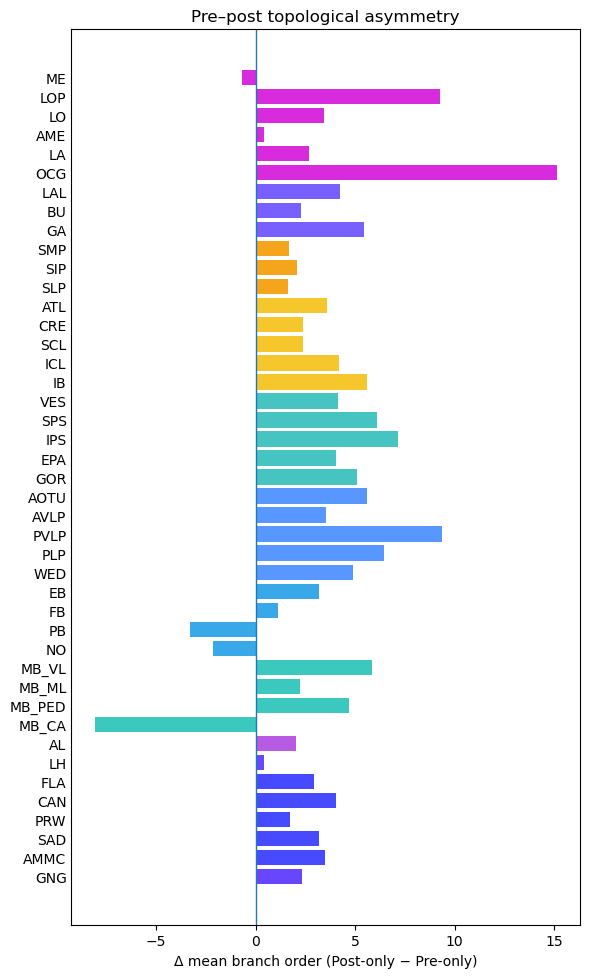

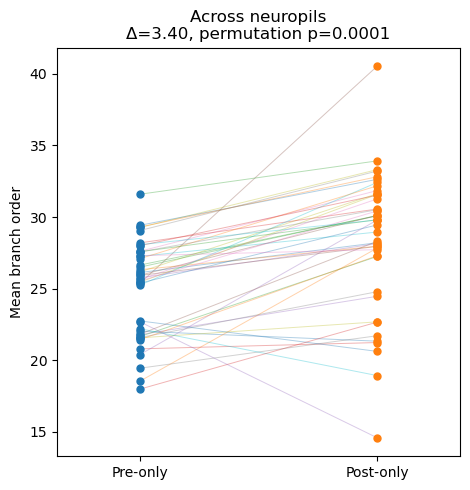

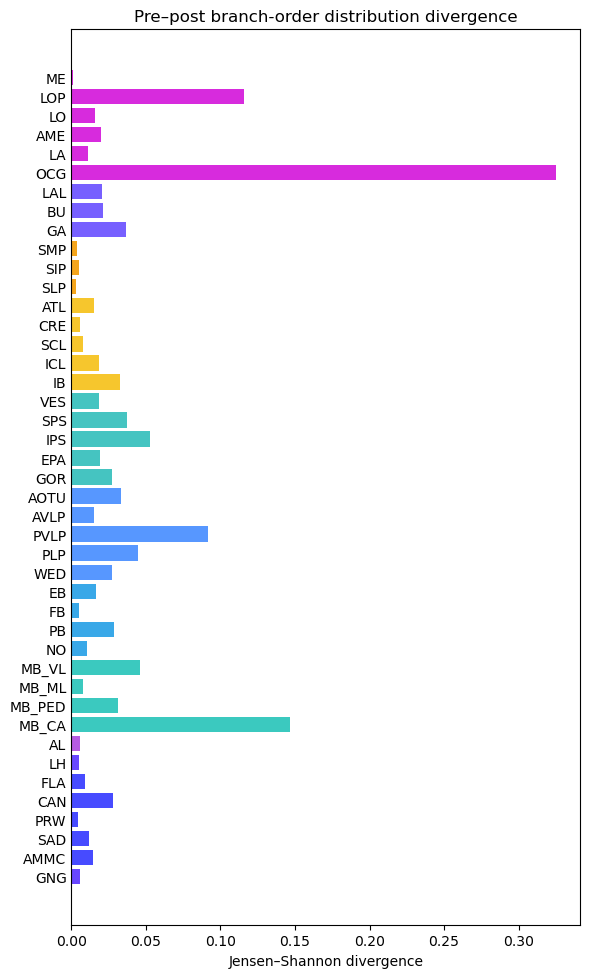

In [5]:
import warnings
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
from scipy.stats import wilcoxon

warnings.filterwarnings("ignore")

OUT=Path("/data/project_backup/swc_fix/branch_order_neuropil_analysis2")
d=pd.read_csv(OUT/"branch_order_per_neuron.csv")

OMIN,OMAX,N_PERM,SEED,DPI=1,60,10000,0,300
ORDERS=np.arange(OMIN,OMAX+1)
rng=np.random.default_rng(SEED)

GROUPS=[
("Optic Lobe",["ME","LOP","LO","AME","LA","OCG"]),
("Lateral Complex",["LAL","BU","GA"]),
("Superior Protocerebrum",["SMP","SIP","SLP"]),
("Inferior Protocerebrum",["ATL","CRE","SCL","ICL","IB"]),
("Ventromedial",["VES","SPS","IPS","EPA","GOR"]),
("Ventrolateral",["AOTU","AVLP","PVLP","PLP","WED"]),
("Central Complex",["EB","FB","PB","NO"]),
("Mushroom Body",["MB_VL","MB_ML","MB_PED","MB_CA"]),
("Antennal Lobe",["AL"]),("Lateral Horn",["LH"]),
("Periesophageal",["FLA","CAN","PRW","SAD","AMMC"]),
("Gnathal Ganglia",["GNG"])]

GC={"Optic Lobe":"#d72bdd","Lateral Complex":"#7760ff",
"Superior Protocerebrum":"#f4a51c","Inferior Protocerebrum":"#f6c62d",
"Ventromedial":"#45c4c1","Ventrolateral":"#5797ff",
"Central Complex":"#39a8e8","Mushroom Body":"#3bc9bf",
"Antennal Lobe":"#b65be2","Lateral Horn":"#6848ff",
"Periesophageal":"#474bff","Gnathal Ganglia":"#6846ff"}

GROUP={n:g for g,ns in GROUPS for n in ns}
ORDER=[n for _,ns in GROUPS for n in ns]

d["neuropil"]=d.neuropil.astype(str).str.replace(r"_(L|R)$","",regex=True)
d=d[d.node_type.isin([2,3])&d.branch_order.between(OMIN,OMAX)&d.neuropil.isin(GROUP)]

def profile(t):
    x=(d[d.node_type==t]
       .groupby(["neuropil","branch_order"]).node_count.sum()
       .unstack(fill_value=0).reindex(columns=ORDERS,fill_value=0))
    return x.div(x.sum(1),axis=0).fillna(0)

pre,post=profile(2),profile(3)
names=[n for n in ORDER if n in pre.index and n in post.index]
pre,post=pre.loc[names],post.loc[names]

P,Q=pre.to_numpy(),post.to_numpy()
pre_bo=P@ORDERS
post_bo=Q@ORDERS
delta=post_bo-pre_bo
js=np.array([jensenshannon(p,q,base=2)**2 for p,q in zip(P,Q)])

res=pd.DataFrame({
    "neuropil":names,"group":[GROUP[n] for n in names],
    "pre_mean_order":pre_bo,"post_mean_order":post_bo,
    "delta_post_minus_pre":delta,"js_divergence":js
})
res.to_csv(OUT/"pre_post_neuropil_topology_metrics_pooled.csv",index=False)

obs=delta.mean()
null=np.array([(delta*rng.choice([-1,1],len(delta))).mean() for _ in range(N_PERM)])
p_perm=(np.sum(np.abs(null)>=abs(obs))+1)/(N_PERM+1)
w,p_wil=wilcoxon(delta)

pd.DataFrame({
    "metric":["mean_delta","permutation_p","wilcoxon_W","wilcoxon_p"],
    "value":[obs,p_perm,w,p_wil]
}).to_csv(OUT/"pre_post_global_statistics_pooled.csv",index=False)

print(f"N neuropils: {len(names)}")
print(f"Mean ΔBO (Post-Pre): {obs:.3f}")
print(f"Permutation p: {p_perm:.5g}")
print(f"Wilcoxon p: {p_wil:.5g}")
print(f"Mean JS divergence: {js.mean():.3f}")

y=np.arange(len(res))
colors=[GC[g] for g in res.group]

# E
fig,ax=plt.subplots(figsize=(6,max(6,len(res)*.23)))
ax.barh(y,res.delta_post_minus_pre,color=colors)
ax.axvline(0,lw=1)
ax.set(yticks=y,yticklabels=res.neuropil,
       xlabel="Δ mean branch order (Post-only − Pre-only)",
       title="Pre–post topological asymmetry")
ax.invert_yaxis(); ax.tick_params(axis="y",length=0)
fig.tight_layout()
fig.savefig(OUT/"pre_post_delta_branch_order_pooled.png",dpi=DPI,bbox_inches="tight")
fig.savefig(OUT/"pre_post_delta_branch_order_pooled.pdf",bbox_inches="tight")
plt.show()

# F
fig,ax=plt.subplots(figsize=(4.8,5))
for a,b in zip(pre_bo,post_bo): ax.plot([0,1],[a,b],lw=.7,alpha=.35)
ax.scatter(np.zeros(len(pre_bo)),pre_bo,s=25,zorder=3)
ax.scatter(np.ones(len(post_bo)),post_bo,s=25,zorder=3)
ax.set(xlim=(-.35,1.35),xticks=[0,1],xticklabels=["Pre-only","Post-only"],
       ylabel="Mean branch order",
       title=f"Across neuropils\nΔ={obs:.2f}, permutation p={p_perm:.3g}")
fig.tight_layout()
fig.savefig(OUT/"pre_post_paired_branch_order_pooled.png",dpi=DPI,bbox_inches="tight")
plt.show()

# G
fig,ax=plt.subplots(figsize=(6,max(6,len(res)*.23)))
ax.barh(y,res.js_divergence,color=colors)
ax.set(yticks=y,yticklabels=res.neuropil,
       xlabel="Jensen–Shannon divergence",
       title="Pre–post branch-order distribution divergence")
ax.invert_yaxis(); ax.tick_params(axis="y",length=0)
fig.tight_layout()
fig.savefig(OUT/"pre_post_JS_divergence_pooled.png",dpi=DPI,bbox_inches="tight")
plt.show()

100%|█████████████████████████████████████████████████████████| 138904/138904 [20:09<00:00, 114.80it/s]


Pre-only: n=25,215,669, rho=0.0105, p=0.000e+00, median distance=0.2932 μm
Post-only: n=65,723,715, rho=-0.0395, p=0.000e+00, median distance=0.0777 μm


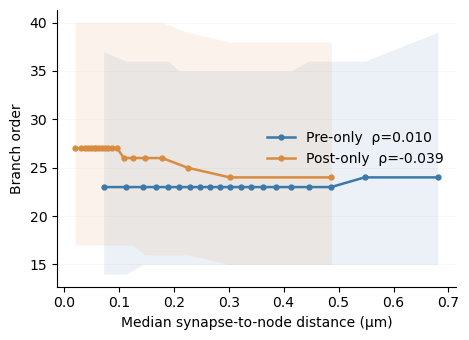

In [8]:
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.stats import spearmanr
from tqdm import tqdm

ROOT=Path("/data/project_backup/swc_fix/step5_2_out")
DETAIL=ROOT/"synapse_assignment_details"
N_WORKERS,CHUNKSIZE=25,20
colors={2:"#3C78A8",3:"#D98C3F"}
labels={2:"Pre-only",3:"Post-only"}

def branch_orders(path):
    a=np.loadtxt(path,comments="#",usecols=(0,1,6),ndmin=2)
    ids,typ,par=a[:,0].astype(np.int64),a[:,1].astype(np.int16),a[:,2].astype(np.int64)
    if not np.any(typ==1): return None,None
    n=len(ids); s=np.argsort(ids); sid=ids[s]; p=np.searchsorted(sid,par)
    v=(par>=0)&(p<n); q=np.flatnonzero(v); v[q]&=sid[p[q]]==par[q]
    parent=np.full(n,-1,np.int32); parent[v]=s[p[v]]
    cc=np.bincount(parent[v],minlength=n); ch=[[] for _ in range(n)]
    for c in np.flatnonzero(v): ch[parent[c]].append(c)
    bo=np.ones(n,np.int16); seen=np.zeros(n,bool)
    for r in np.flatnonzero(parent<0):
        st=[(int(r),0 if typ[r]==1 else 1)]
        while st:
            i,o=st.pop()
            if seen[i]: continue
            seen[i]=1; bo[i]=o
            for c in ch[i]:
                co=1 if o==0 else o
                if cc[c]>=2 and typ[c]!=1: co+=1
                st.append((c,co))
    return ids,bo

def process(job):
    f,swc=map(Path,job)
    try:
        ids,bo=branch_orders(swc)
        if ids is None:return None
        x=pd.read_csv(f,usecols=["syn_type","assigned_node_id","distance_um"])
        if x.empty:return None

        g=(x.groupby(["assigned_node_id","syn_type"])
             .agg(n=("distance_um","size"),distance=("distance_um","median"))
             .reset_index())

        c=g.pivot(index="assigned_node_id",columns="syn_type",values="n").fillna(0)
        pre=c.get("pre",pd.Series(0,index=c.index))
        post=c.get("post",pd.Series(0,index=c.index))
        nodes=c.index[((pre>0)&(post==0))|((pre==0)&(post>0))]
        if not len(nodes): return None

        typ=np.where(pre.loc[nodes].to_numpy()>0,2,3)
        dist=g[g.assigned_node_id.isin(nodes)].set_index("assigned_node_id").loc[nodes,"distance"].to_numpy()
        m=dict(zip(ids,bo))

        z=pd.DataFrame({"node_id":nodes.to_numpy(np.int64),"node_type":typ,"distance_um":dist})
        z["branch_order"]=[m.get(i,np.nan) for i in z.node_id]
        return z.dropna()
    except Exception:
        return None

swc={p.stem:p for p in ROOT.rglob("*.swc")}
details=sorted(DETAIL.rglob("*_synapse_assignment_details.csv"))
jobs=[(str(f),str(swc[n])) for f in details
      if (n:=f.name.replace("_synapse_assignment_details.csv","")) in swc]

parts=[]
with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
    for z in tqdm(ex.map(process,jobs,chunksize=CHUNKSIZE),total=len(jobs)):
        if z is not None: parts.append(z)

df=pd.concat(parts,ignore_index=True)

fig,ax=plt.subplots(figsize=(4.8,3.5))
for t in [2,3]:
    z=df[df.node_type==t].copy()
    rho,p=spearmanr(z.distance_um,z.branch_order)
    print(f"{labels[t]}: n={len(z):,}, rho={rho:.4f}, p={p:.3e}, median distance={z.distance_um.median():.4f} μm")

    z["bin"]=pd.qcut(z.distance_um,20,duplicates="drop")
    q=(z.groupby("bin",observed=True)
       .agg(distance=("distance_um","median"),
            order=("branch_order","median"),
            q25=("branch_order",lambda x:np.quantile(x,.25)),
            q75=("branch_order",lambda x:np.quantile(x,.75)))
       .reset_index())

    ax.plot(q.distance,q.order,lw=1.8,marker="o",ms=3.5,
            color=colors[t],label=f"{labels[t]}  ρ={rho:.3f}")
    ax.fill_between(q.distance,q.q25,q.q75,color=colors[t],alpha=.1,lw=0)

ax.set(xlabel="Median synapse-to-node distance (μm)",ylabel="Branch order")
ax.legend(frameon=False)
ax.spines[["top","right"]].set_visible(False)
ax.tick_params(direction="out")
ax.yaxis.grid(True,lw=.4,alpha=.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(ROOT/"node_distance_branch_order_qc.pdf",bbox_inches="tight")
plt.savefig(ROOT/"node_distance_branch_order_qc.png",dpi=600,bbox_inches="tight")
plt.show()

Same: median=0.8645, mean=0.8478
Different: median=0.7943, mean=0.7757
Rank-biserial r=0.3908
Permutation p=9.999e-05


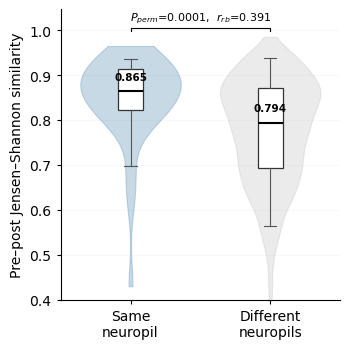

In [7]:
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
from scipy.stats import mannwhitneyu

ROOT=Path("/data/project_backup/swc_fix/branch_order_neuropil_analysis2")
d=pd.read_csv(ROOT/"branch_order_per_neuron.csv")

OMIN,OMAX,N_PERM,SEED=1,60,10000,42
ORDERS=np.arange(OMIN,OMAX+1)
colors=["#3C78A8","#B8B8B8"]

d["neuropil"]=d.neuropil.astype(str).str.replace(r"_(L|R)$","",regex=True)
d=d[d.node_type.isin([2,3])&
    d.branch_order.between(OMIN,OMAX)&
    (d.neuropil!="OUTSIDE")&
    ~d.neuropil.str.contains(r"\|",regex=True)].copy()

def profile(t):
    x=(d[d.node_type==t]
       .groupby(["neuropil","branch_order"]).node_count.sum()
       .unstack(fill_value=0)
       .reindex(columns=ORDERS,fill_value=0))
    return x.div(x.sum(1),axis=0).fillna(0)

def jss(a,b):
    return 1-jensenshannon(a,b,base=2)

pre,post=profile(2),profile(3)
neu=sorted(set(pre.index)&set(post.index))
pre,post=pre.loc[neu],post.loc[neu]

same=np.array([jss(pre.loc[n],post.loc[n]) for n in neu])
different=np.array([
    jss(pre.loc[a],post.loc[b])
    for a in neu for b in neu if a!=b
])

u=mannwhitneyu(same,different,alternative="two-sided")
rrb=2*u.statistic/(len(same)*len(different))-1

rng=np.random.default_rng(SEED)
obs=same.mean()
null=np.array([
    np.mean([jss(pre.loc[a],post.loc[b])
             for a,b in zip(neu,rng.permutation(neu))])
    for _ in range(N_PERM)
])
p_perm=(np.sum(null>=obs)+1)/(N_PERM+1)

print(f"Same: median={np.median(same):.4f}, mean={same.mean():.4f}")
print(f"Different: median={np.median(different):.4f}, mean={different.mean():.4f}")
print(f"Rank-biserial r={rrb:.4f}")
print(f"Permutation p={p_perm:.4g}")

fig,ax=plt.subplots(figsize=(3.6,3.6))
data=[same,different]; pos=[1,2]

v=ax.violinplot(data,positions=pos,widths=.72,showextrema=False)
for body,c in zip(v["bodies"],colors):
    body.set_facecolor(c); body.set_edgecolor(c)
    body.set_alpha(.28); body.set_linewidth(.8)

ax.boxplot(
    data,positions=pos,widths=.18,patch_artist=True,
    showfliers=False,whis=(5,95),
    boxprops=dict(facecolor="white",edgecolor="#333333",lw=.9),
    whiskerprops=dict(color="#555555",lw=.8),
    capprops=dict(color="#555555",lw=.8),
    medianprops=dict(color="black",lw=1.5)
)

ymax=max(np.max(same),np.quantile(different,.995))
ymin=min(np.min(same),np.quantile(different,.01))
yr=ymax-ymin
y=ymax+.07*yr

ax.plot([1,1,2,2],[y-.012*yr,y,y,y-.012*yr],
        color="black",lw=.8,clip_on=False)
ax.text(1.5,y+.012*yr,
        f"$P_{{perm}}$={p_perm:.3g},  $r_{{rb}}$={rrb:.3f}",
        ha="center",va="bottom",fontsize=8)

ax.text(1,np.median(same)+.025,f"{np.median(same):.3f}",
        ha="center",fontsize=7.5,fontweight="semibold")
ax.text(2,np.median(different)+.025,f"{np.median(different):.3f}",
        ha="center",fontsize=7.5,fontweight="semibold")

ax.set(
    xticks=pos,
    xticklabels=["Same\nneuropil","Different\nneuropils"],
    ylabel="Pre–post Jensen–Shannon similarity"
)

ax.set_ylim(ymin-.03,y+.08*yr)
ax.spines[["top","right"]].set_visible(False)
ax.tick_params(direction="out",width=.8,length=3)
ax.yaxis.grid(True,lw=.4,alpha=.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(ROOT/"pre_post_neuropil_similarity_pooled.pdf",bbox_inches="tight")
plt.savefig(ROOT/"pre_post_neuropil_similarity_pooled.png",dpi=600,bbox_inches="tight")
plt.show()


BIN: Δ=3.463, P=9.999e-05, Post>Pre=39/43
NO-BIN: Δ=3.396, P=9.999e-05, Post>Pre=39/43
Δ robustness: rho=0.996, P=3.83e-44, MAE=0.137, median=0.076
Pre similarity : median=0.9750, mean=0.9661, min=0.8901
Post similarity: median=0.9755, mean=0.9696, min=0.9224


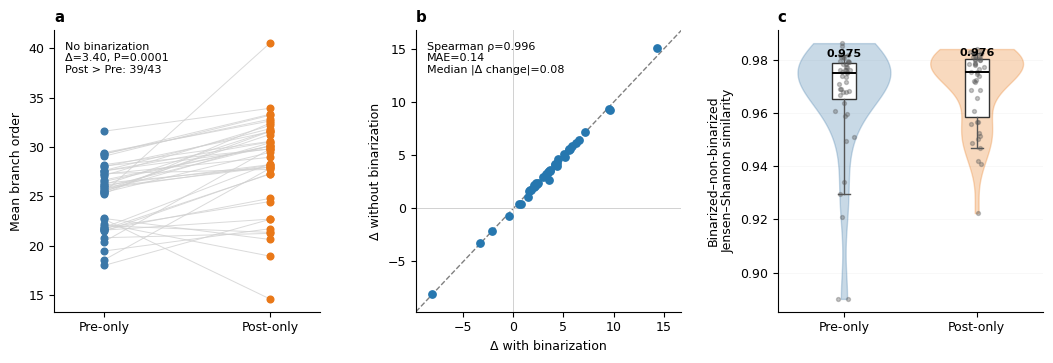

In [14]:
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr

A=Path("/data/project_backup/swc_fix/branch_order_neuropil_analysis")
B=Path("/data/project_backup/swc_fix/branch_order_neuropil_analysis2")
OUT=B/"figureS6"; OUT.mkdir(exist_ok=True)
ORD=np.arange(1,61); NPERM=10000

GROUPS=[
("Optic Lobe",["ME","LOP","LO","AME","LA","OCG"]),
("Lateral Complex",["LAL","BU","GA"]),
("Superior Protocerebrum",["SMP","SIP","SLP"]),
("Inferior Protocerebrum",["ATL","CRE","SCL","ICL","IB"]),
("Ventromedial",["VES","SPS","IPS","EPA","GOR"]),
("Ventrolateral",["AOTU","AVLP","PVLP","PLP","WED"]),
("Central Complex",["EB","FB","PB","NO"]),
("Mushroom Body",["MB_VL","MB_ML","MB_PED","MB_CA"]),
("Antennal Lobe",["AL"]),("Lateral Horn",["LH"]),
("Periesophageal",["FLA","CAN","PRW","SAD","AMMC"]),
("Gnathal Ganglia",["GNG"])]
ORDER=[n for _,ns in GROUPS for n in ns]

def load(root):
    d=pd.read_csv(root/"branch_order_per_neuron.csv")
    d["neuropil"]=d.neuropil.astype(str).str.replace(r"_(L|R)$","",regex=True)
    return d[d.node_type.isin([2,3])&d.branch_order.between(1,60)&
             (d.neuropil!="OUTSIDE")&~d.neuropil.str.contains(r"\|",regex=True)].copy()

def prof(d,t):
    x=(d[d.node_type==t].groupby(["neuropil","branch_order"]).node_count.sum()
       .unstack(fill_value=0).reindex(columns=ORD,fill_value=0))
    return x.div(x.sum(1),axis=0).fillna(0)

def delta(root):
    d=load(root); pre,post=prof(d,2),prof(d,3)
    ns=[n for n in ORDER if n in pre.index and n in post.index]
    a,b=pre.loc[ns].values@ORD,post.loc[ns].values@ORD
    x=b-a; rng=np.random.default_rng(0); obs=x.mean()
    null=np.array([(x*rng.choice([-1,1],len(x))).mean() for _ in range(NPERM)])
    p=(np.sum(np.abs(null)>=abs(obs))+1)/(NPERM+1)
    return pd.DataFrame({"neuropil":ns,"pre":a,"post":b,"delta":x}),obs,p

ma,da,pa=delta(A); mb,db,pb=delta(B)
m=ma.merge(mb,on="neuropil",suffixes=("_bin","_nobin"))
rho,pr=spearmanr(m.delta_bin,m.delta_nobin)
chg=np.abs(m.delta_bin-m.delta_nobin); mae,medae=chg.mean(),np.median(chg)
na,nb=(ma.delta>0).sum(),(mb.delta>0).sum()

dA,dB=load(A),load(B)
pA,qA,pB,qB=prof(dA,2),prof(dA,3),prof(dB,2),prof(dB,3)
ns=m.neuropil.tolist()
jss=lambda a,b:1-jensenshannon(a,b,base=2)
pre_sim=np.array([jss(pA.loc[n],pB.loc[n]) for n in ns])
post_sim=np.array([jss(qA.loc[n],qB.loc[n]) for n in ns])

print(f"\nBIN: Δ={da:.3f}, P={pa:.4g}, Post>Pre={na}/{len(ma)}")
print(f"NO-BIN: Δ={db:.3f}, P={pb:.4g}, Post>Pre={nb}/{len(mb)}")
print(f"Δ robustness: rho={rho:.3f}, P={pr:.3g}, MAE={mae:.3f}, median={medae:.3f}")
print(f"Pre similarity : median={np.median(pre_sim):.4f}, mean={pre_sim.mean():.4f}, min={pre_sim.min():.4f}")
print(f"Post similarity: median={np.median(post_sim):.4f}, mean={post_sim.mean():.4f}, min={post_sim.min():.4f}")

plt.rcParams.update({"font.size":9,"axes.spines.top":False,"axes.spines.right":False})
fig,(a,b,c)=plt.subplots(1,3,figsize=(10.6,3.7))

for x,y in zip(mb.pre,mb.post): a.plot([0,1],[x,y],c=".82",lw=.7,alpha=.8)
a.scatter(np.zeros(len(mb)),mb.pre,s=23,c="#3C78A8",zorder=3)
a.scatter(np.ones(len(mb)),mb.post,s=23,c="#E97818",zorder=3)
a.set(xlim=(-.3,1.3),xticks=[0,1],xticklabels=["Pre-only","Post-only"],ylabel="Mean branch order")
a.set_title("a",loc="left",fontweight="bold")
a.text(.04,.96,f"No binarization\nΔ={db:.2f}, P={pb:.3g}\nPost > Pre: {nb}/{len(mb)}",
       transform=a.transAxes,va="top",fontsize=8)

x,y=m.delta_bin.values,m.delta_nobin.values
lo,hi=min(x.min(),y.min()),max(x.max(),y.max()); pad=.07*(hi-lo); lo-=pad; hi+=pad
b.scatter(x,y,s=28,c="#2677AF",zorder=3)
b.plot([lo,hi],[lo,hi],"--",c=".5",lw=1)
b.axhline(0,c=".82",lw=.7); b.axvline(0,c=".82",lw=.7)
b.set(xlim=(lo,hi),ylim=(lo,hi),xlabel="Δ with binarization",ylabel="Δ without binarization")
b.set_title("b",loc="left",fontweight="bold")
b.text(.04,.96,f"Spearman ρ={rho:.3f}\nMAE={mae:.2f}\nMedian |Δ change|={medae:.2f}",
       transform=b.transAxes,va="top",fontsize=8)

data=[pre_sim,post_sim]; pos=[1,2]; cols=["#3C78A8","#E97818"]
v=c.violinplot(data,positions=pos,widths=.7,showextrema=False)
for body,col in zip(v["bodies"],cols):
    body.set_facecolor(col); body.set_edgecolor(col); body.set_alpha(.28)

c.boxplot(data,positions=pos,widths=.18,patch_artist=True,showfliers=False,whis=(5,95),
          boxprops=dict(facecolor="white",edgecolor="#333"),
          whiskerprops=dict(color="#555"),capprops=dict(color="#555"),
          medianprops=dict(color="black",lw=1.4))

rng=np.random.default_rng(42)
for i,z in zip(pos,data):
    c.scatter(rng.normal(i,.035,len(z)),z,s=8,c=".35",alpha=.35,zorder=2)
    c.text(i,np.median(z)+.006,f"{np.median(z):.3f}",ha="center",fontsize=8,fontweight="semibold")

c.set(xticks=pos,xticklabels=["Pre-only","Post-only"],
      ylabel="Binarized–non-binarized\nJensen–Shannon similarity")
c.set_title("c",loc="left",fontweight="bold")
c.yaxis.grid(True,lw=.4,alpha=.15); c.set_axisbelow(True)

fig.tight_layout(w_pad=2)
for ext in ["pdf","png","svg"]:
    fig.savefig(OUT/f"Figure_S6_binarization_robustness.{ext}",
                dpi=600 if ext=="png" else None,bbox_inches="tight")
plt.show()

m["abs_delta_change"]=chg
m.to_csv(OUT/"Figure_S6_neuropil_delta_comparison.csv",index=False)

pd.DataFrame({
    "neuropil":ns,
    "pre_similarity":pre_sim,
    "post_similarity":post_sim
}).to_csv(OUT/"Figure_S6_distribution_similarity.csv",index=False)

pd.DataFrame({
    "synapse_type":["Pre-only","Post-only"],
    "median_similarity":[np.median(pre_sim),np.median(post_sim)],
    "mean_similarity":[pre_sim.mean(),post_sim.mean()],
    "min_similarity":[pre_sim.min(),post_sim.min()]
}).to_csv(OUT/"Figure_S6_distribution_similarity_summary.csv",index=False)